# 04 - Community Detection (Louvain vs Spectral)

Mục tiêu:
- Chạy Louvain với `resolution = 0.5, 1.0, 1.5` và tính Modularity Q.
- Chạy Spectral Clustering với `k = 3, 4, 5` và tính Silhouette score.
- So sánh kết quả 2 phương pháp theo từng quận.
- Xuất file `data/processed/community_labels.csv` để dùng cho báo cáo ngày 2.


In [1]:
# Neu chua cai, bo comment dong duoi va chay 1 lan
!pip install python-louvain scikit-learn networkx pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns

# Them src vao PYTHONPATH
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from community_detection import (
    load_graph_from_csv,
    run_louvain_grid,
    run_spectral_grid,
    pick_best_louvain,
    pick_best_spectral,
    compare_partitions,
    export_community_labels,
    export_metric_summary,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
from pathlib import Path

_cwd = Path.cwd().resolve()
ROOT_CANDIDATES = [_cwd, _cwd.parent]
ROOT = None
for c in ROOT_CANDIDATES:
    if (c / 'data' / 'processed').exists() and (c / 'src').exists():
        ROOT = c
        break
if ROOT is None:
    ROOT = _cwd

NODES_PATH = ROOT / 'data' / 'processed' / 'graph_nodes.csv'
EDGES_PATH = ROOT / 'data' / 'processed' / 'graph_edges.csv'
CENTRALITY_PATH = ROOT / 'data' / 'processed' / 'centrality_scores.csv'
OUT_LABELS_PATH = ROOT / 'data' / 'processed' / 'community_labels.csv'
OUT_METRICS_PATH = ROOT / 'data' / 'processed' / 'community_metrics_summary.csv'

print('ROOT:', ROOT)
print('Nodes file      :', NODES_PATH)
print('Edges file      :', EDGES_PATH)
print('Centrality file :', CENTRALITY_PATH)
print('Output labels   :', OUT_LABELS_PATH)
print('Output metrics  :', OUT_METRICS_PATH)

missing = [str(p) for p in [NODES_PATH, EDGES_PATH] if not p.exists()]
if missing:
    raise FileNotFoundError('Thieu input file: ' + ', '.join(missing))

ROOT: D:\HK2_N3\graphmining\Day1_ML & Analysis
Nodes file      : D:\HK2_N3\graphmining\Day1_ML & Analysis\data\processed\graph_nodes.csv
Edges file      : D:\HK2_N3\graphmining\Day1_ML & Analysis\data\processed\graph_edges.csv
Centrality file : D:\HK2_N3\graphmining\Day1_ML & Analysis\data\processed\centrality_scores.csv
Output labels   : D:\HK2_N3\graphmining\Day1_ML & Analysis\data\processed\community_labels.csv
Output metrics  : D:\HK2_N3\graphmining\Day1_ML & Analysis\data\processed\community_metrics_summary.csv


In [5]:
# Load do thi
G = load_graph_from_csv(str(NODES_PATH), str(EDGES_PATH), node_id_col='district')

print(f'So node: {G.number_of_nodes()}')
print(f'So edge: {G.number_of_edges()}')
print(f'Connected: {nx.is_connected(G)}')

So node: 22
So edge: 54
Connected: True


In [6]:
# Chay Louvain voi nhieu resolution
louvain_results = run_louvain_grid(G, resolutions=(0.5, 1.0, 1.5), seed=42)
louvain_scores = pd.DataFrame([
    {'resolution': r.resolution, 'modularity_q': r.modularity_q, 'n_communities': len(set(r.labels.values()))}
    for r in louvain_results
]).sort_values('modularity_q', ascending=False)

louvain_scores

,resolution,modularity_q,n_communities
2,1.5,0.321845,5
1,1.0,0.312586,4
0,0.5,0.294753,4


In [7]:
# Chay Spectral voi k = 3,4,5
spectral_results = run_spectral_grid(G, n_clusters_list=(3, 4, 5), seed=42)
spectral_scores = pd.DataFrame([
    {'k': r.n_clusters, 'silhouette': r.silhouette}
    for r in spectral_results
]).sort_values('silhouette', ascending=False)

spectral_scores

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,k,silhouette
0,3,-0.009940
2,5,-0.050176
1,4,-0.058995


In [8]:
# Chon cau hinh tot nhat theo metric
best_louvain = pick_best_louvain(louvain_results)
best_spectral = pick_best_spectral(spectral_results)

print('Best Louvain resolution:', best_louvain.resolution)
print('Best Louvain modularity Q:', round(best_louvain.modularity_q, 4))
print('Best Spectral k:', best_spectral.n_clusters)
print('Best Spectral silhouette:', round(best_spectral.silhouette, 4))

Best Louvain resolution: 1.5
Best Louvain modularity Q: 0.3218
Best Spectral k: 3
Best Spectral silhouette: -0.0099


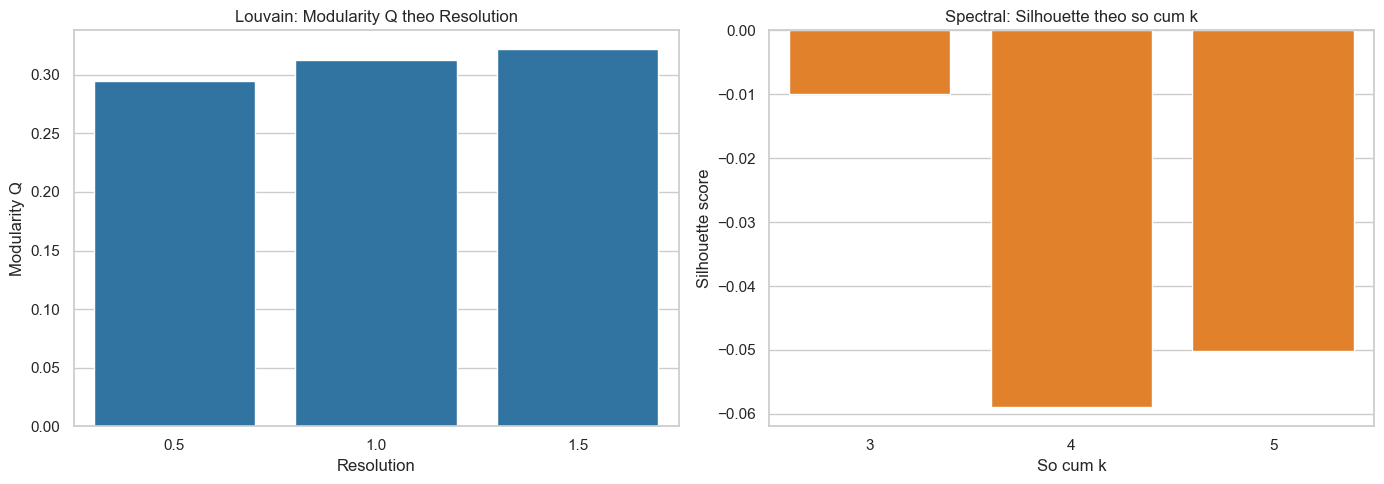

In [9]:
# Ve bieu do metric de so sanh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=louvain_scores, x='resolution', y='modularity_q', ax=axes[0], color='#1f77b4')
axes[0].set_title('Louvain: Modularity Q theo Resolution')
axes[0].set_xlabel('Resolution')
axes[0].set_ylabel('Modularity Q')

sns.barplot(data=spectral_scores, x='k', y='silhouette', ax=axes[1], color='#ff7f0e')
axes[1].set_title('Spectral: Silhouette theo so cum k')
axes[1].set_xlabel('So cum k')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.show()

In [10]:
# So sanh gan nhan cum theo tung quan
comparison_df = compare_partitions(best_louvain.labels, best_spectral.labels)
comparison_df = comparison_df.sort_values('district').reset_index(drop=True)
comparison_df.head(22)

,district,louvain_community,spectral_cluster
0,BìnhChánh,0,0
1,BìnhThạnh,2,1
2,BìnhTân,1,0
3,CầnGiờ,0,2
4,CủChi,3,0
5,GòVấp,2,1
6,HócMôn,3,0
7,NhàBè,0,2
8,PhúNhuận,2,1
9,Quận1,4,1


In [11]:
# Bang cheo de xem muc do trung khop giua 2 cach phan cum
crosstab_df = pd.crosstab(
    comparison_df['louvain_community'],
    comparison_df['spectral_cluster'],
    rownames=['Louvain'],
    colnames=['Spectral']
)
crosstab_df

Spectral,0,1,2
Louvain,,,
0,1,3,3
1,1,3,0
2,0,5,0
3,2,0,0
4,0,4,0


## Visualization Cụm Trên Đồ Thị

Hai hình dưới đây tô màu node theo:
- Louvain community (best resolution)
- Spectral cluster (best k)

Màu giống nhau trong từng hình nghĩa là cùng cụm.


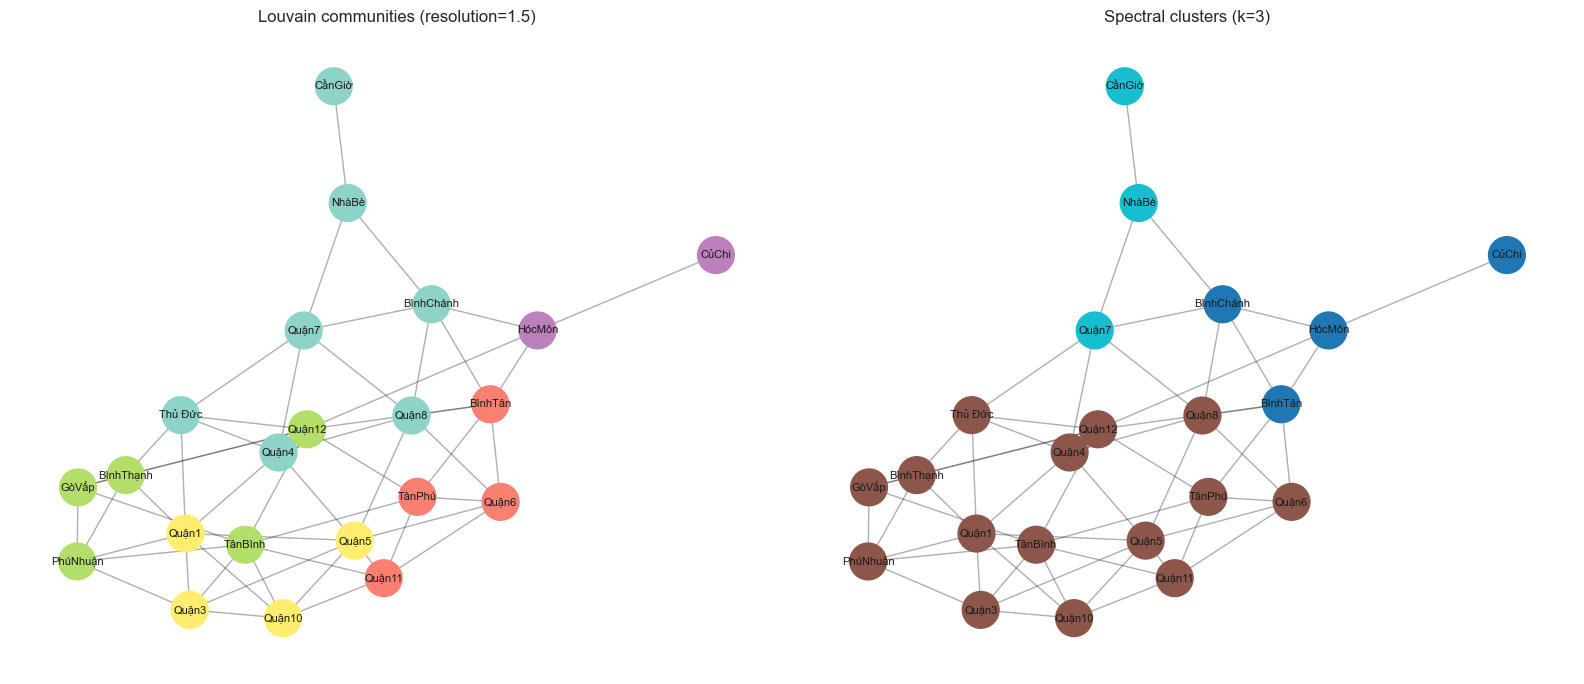

In [12]:
import numpy as np

# Lay vi tri node co dinh de so sanh cong bang giua 2 phuong phap
nodes = sorted(G.nodes())
pos = nx.spring_layout(G, seed=42, weight='weight')

# Chuyen labels ve dung thu tu node
louvain_labels_arr = np.array([best_louvain.labels[n] for n in nodes])
spectral_labels_arr = np.array([best_spectral.labels[n] for n in nodes])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Louvain
nx.draw_networkx_nodes(
    G, pos, nodelist=nodes, node_color=louvain_labels_arr,
    cmap=plt.cm.Set3, node_size=700, ax=axes[0]
)
nx.draw_networkx_edges(G, pos, alpha=0.35, width=1.0, ax=axes[0])
nx.draw_networkx_labels(G, pos, font_size=8, ax=axes[0])
axes[0].set_title(f'Louvain communities (resolution={best_louvain.resolution})')
axes[0].axis('off')

# Spectral
nx.draw_networkx_nodes(
    G, pos, nodelist=nodes, node_color=spectral_labels_arr,
    cmap=plt.cm.tab10, node_size=700, ax=axes[1]
)
nx.draw_networkx_edges(G, pos, alpha=0.35, width=1.0, ax=axes[1])
nx.draw_networkx_labels(G, pos, font_size=8, ax=axes[1])
axes[1].set_title(f'Spectral clusters (k={best_spectral.n_clusters})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Xuat ket qua
OUT_LABELS_PATH.parent.mkdir(parents=True, exist_ok=True)

export_community_labels(
    out_path=str(OUT_LABELS_PATH),
    comparison_df=comparison_df,
    louvain_resolution=best_louvain.resolution,
    spectral_k=best_spectral.n_clusters,
)

summary_df = export_metric_summary(
    out_path=str(OUT_METRICS_PATH),
    louvain_results=louvain_results,
    spectral_results=spectral_results,
)

print('Da luu:', OUT_LABELS_PATH)
print('Da luu:', OUT_METRICS_PATH)
summary_df

Da luu: D:\HK2_N3\graphmining\Day1_ML & Analysis\data\processed\community_labels.csv
Da luu: D:\HK2_N3\graphmining\Day1_ML & Analysis\data\processed\community_metrics_summary.csv


,method,setting,score
0,louvain,0.5,0.294753
1,louvain,1.0,0.312586
2,louvain,1.5,0.321845
3,spectral,3.0,-0.009940
4,spectral,4.0,-0.058995
5,spectral,5.0,-0.050176


## nhận xét
1. Nếu `modularity Q` của Louvain cao và ổn định ở nhiều `resolution`, các cụm của Louvain thường dễ giải thích theo cấu trúc liên kết thực tế.
2. Nếu Spectral cho `silhouette` cao rõ ràng tại một giá trị `k`, có thể xem đây là gợi ý về số cụm tối ưu theo hình học của ma trận kề.
3. Đối chiếu với dữ liệu ca bệnh: các quận nằm cùng cụm và có số ca cao có thể được xem là ổ dịch liên vùng.
4. Nếu hai phương pháp cho kết quả khác nhau, nên ưu tiên cách diễn giải phù hợp về mặt nghiệp vụ và bối cảnh địa lý - giao thông.
